In [ ]:
# install required libaries for object detection and dataset access
!pip install ultralytics roboflow --quiet


import torch

# verify GPU availibility
print("GPU available:", torch.cuda.is_available())
print("Device name: ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU — check Accelerator in Session options!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.3 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
GPU available: True
Device name:  Tesla T4


In [ ]:
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient

# securely retrieve API key instead of hardcoding credentials
user_secrets = UserSecretsClient()
ROBOFLOW_API_KEY = user_secrets.get_secret("ROBOFLOW_API_KEY")

# centralise dataset configuration
WORKSPACE_NAME   = "workspace-yzeqy"        # Roboflow workspace slug
PROJECT_NAME     = "volog"                  # project slug
VERSION_NUMBER   = 2                        # dataset version number

# download dataset in YOLOv8 format to match training pipeline 
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
dataset = project.version(VERSION_NUMBER).download("yolov8")

print("\nDataset downloaded to:", dataset.location)
print("Config file: ", dataset.location + "/data.yaml")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to VOLog-2 in yolov8:: 100%|██████████| 599/599 [00:00<00:00, 6235.53it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset downloaded to: /kaggle/working/VOLog-2
Config file:  /kaggle/working/VOLog-2/data.yaml


In [ ]:
import yaml, os

# use explicit path to avoid ambiguity
DATA_YAML = "/kaggle/working/VOLog-2/data.yaml"  # hardcoding the path is more reliable in this case

# inspect dataset configuration to validate paths and class structure
with open(DATA_YAML) as f:
    config = yaml.safe_load(f)

print("=== data.yaml contents ===")
print(yaml.dump(config, default_flow_style=False))

# sanity check - ensure dataaset splits exist and contain images
for split in ['train', 'valid', 'test']:
    path = config.get(split, '')
    if path and os.path.exists(path):
        n = len(os.listdir(path))
        print(f"{split}: {n} images")
    else:
        print(f"{split}: path not found ({path})")

=== data.yaml contents ===
names:
- car
- person
nc: 2
roboflow:
  license: CC BY 4.0
  project: volog
  url: https://universe.roboflow.com/workspace-yzeqy/volog/dataset/2
  version: 2
  workspace: workspace-yzeqy
test: ../test/images
train: ../train/images
val: ../valid/images

train: path not found (../train/images)
valid: path not found ()
test: path not found (../test/images)


In [ ]:
from ultralytics import YOLO

# initialise pretrained weight to have faster convergence
model = YOLO('yolov8s.pt')

# architecture and parameter count for verification
print(model.info())

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs
(129, 11166560, 0, 28.816844800000002)


In [ ]:
from ultralytics import YOLO

DATA_YAML = "/kaggle/working/VOLog-2/data.yaml"

# reload model to ensure clean training state
model = YOLO('yolov8s.pt')

# train model with augmentation
results = model.train(
    data        = DATA_YAML,
    epochs      = 100,
    imgsz       = 640,
    batch       = 16,
    patience    = 20,    # early stoppung to prevent overfitting
    optimizer   = 'AdamW',     # better weight decay handling than other optimizers
    lr0         = 0.001,
    cos_lr      = True,      # smoother learning rate decay

    # online augmentation - the dataset does not increase
    degrees     = 5.0,
    hsv_h       = 0.015,
    hsv_s       = 0.5,
    hsv_v       = 0.4,
    fliplr      = 0.5,
    flipud      = 0.0,
    scale       = 0.3,
    translate   = 0.1,
    mosaic      = 0.5,
    erasing     = 0.2,

    # organise outputs for reproducability and version tracking 
    project     = '/kaggle/working/volog_runs',
    name        = 'occupancy_v1',
    exist_ok    = True,
    verbose     = True
)

print("\nTraining complete.")
print("Best weights saved at:", str(results.save_dir) + '/weights/best.pt')

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/VOLog-2/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=occupancy_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, p

In [ ]:
from ultralytics import YOLO

DATA_YAML    = "/kaggle/working/VOLog-2/data.yaml"
BEST_WEIGHTS = "/kaggle/working/volog_runs/occupancy_v1/weights/best.pt"

# load best performing checkpoint instead of final epoch weights
best_model = YOLO(BEST_WEIGHTS)

# evaluate on test set to measure real world performance
metrics = best_model.val(
    data   = DATA_YAML,
    split  = 'test',
    imgsz  = 640,
    batch  = 16
)

# report key detection metrics
print("\n=== Test Set Results ===")
print(f"mAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1749.3±632.6 MB/s, size: 89.9 KB)
val: Scanning /kaggle/working/VOLog-2/test/labels... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 1.3Kit/s 0.0s
val: New cache created: /kaggle/working/VOLog-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s1.1s
                   all         31         79      0.934      0.911      0.945      0.655
                   car         31         32      0.962          1      0.983      0.849
                person         31         47      0.906      0.821      0.907       0.46
Speed: 3.9ms preprocess, 11.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

=== Test Set Results ===
mAP


--- results.png ---


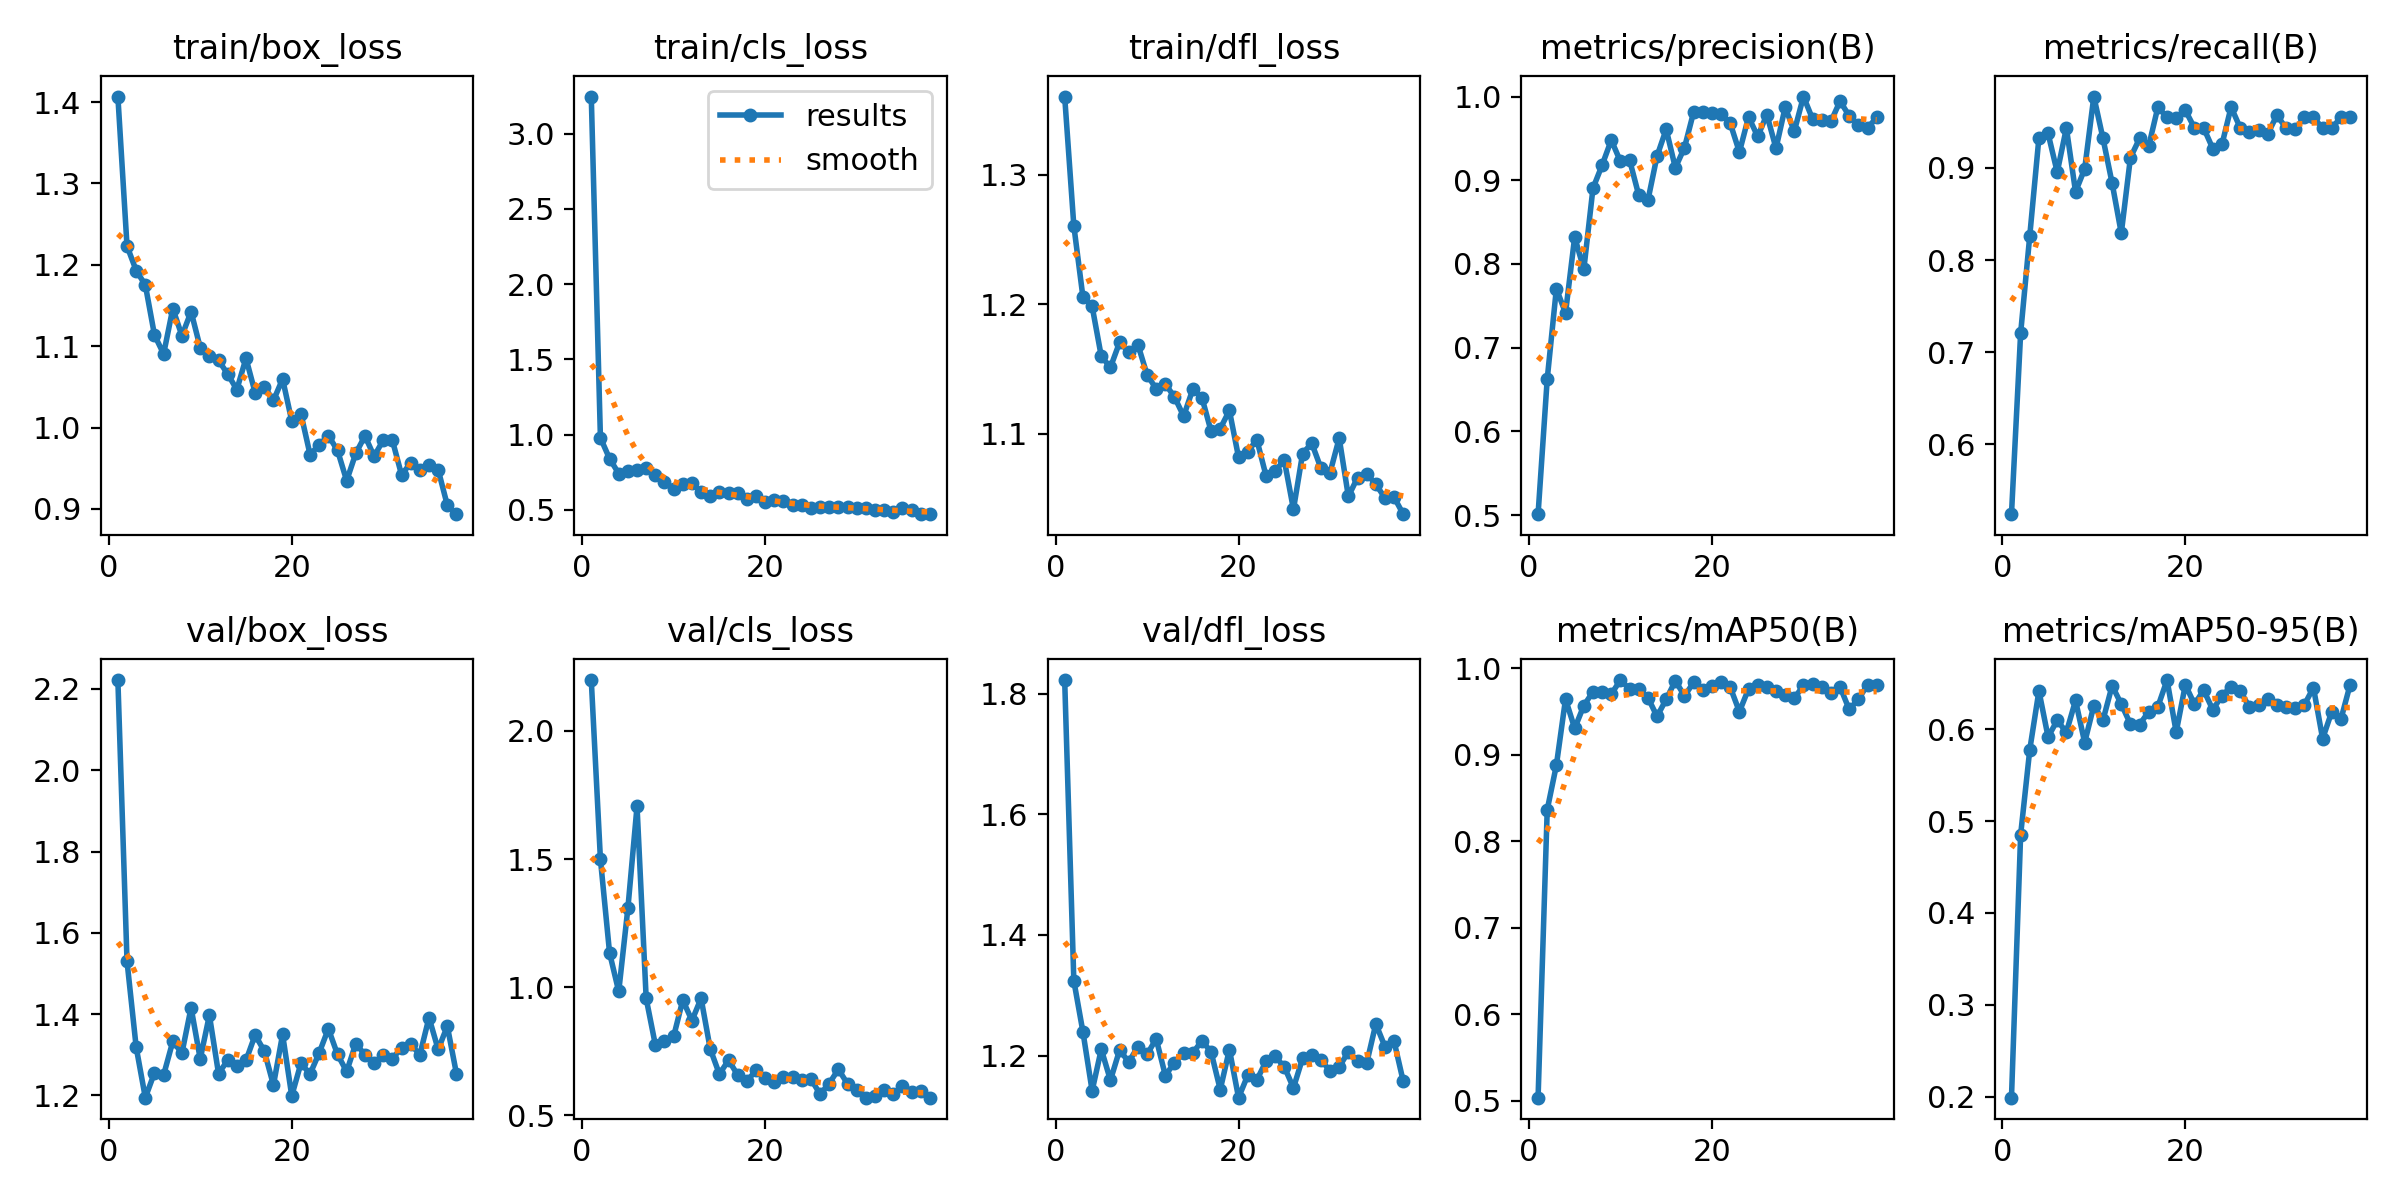


--- confusion_matrix.png ---


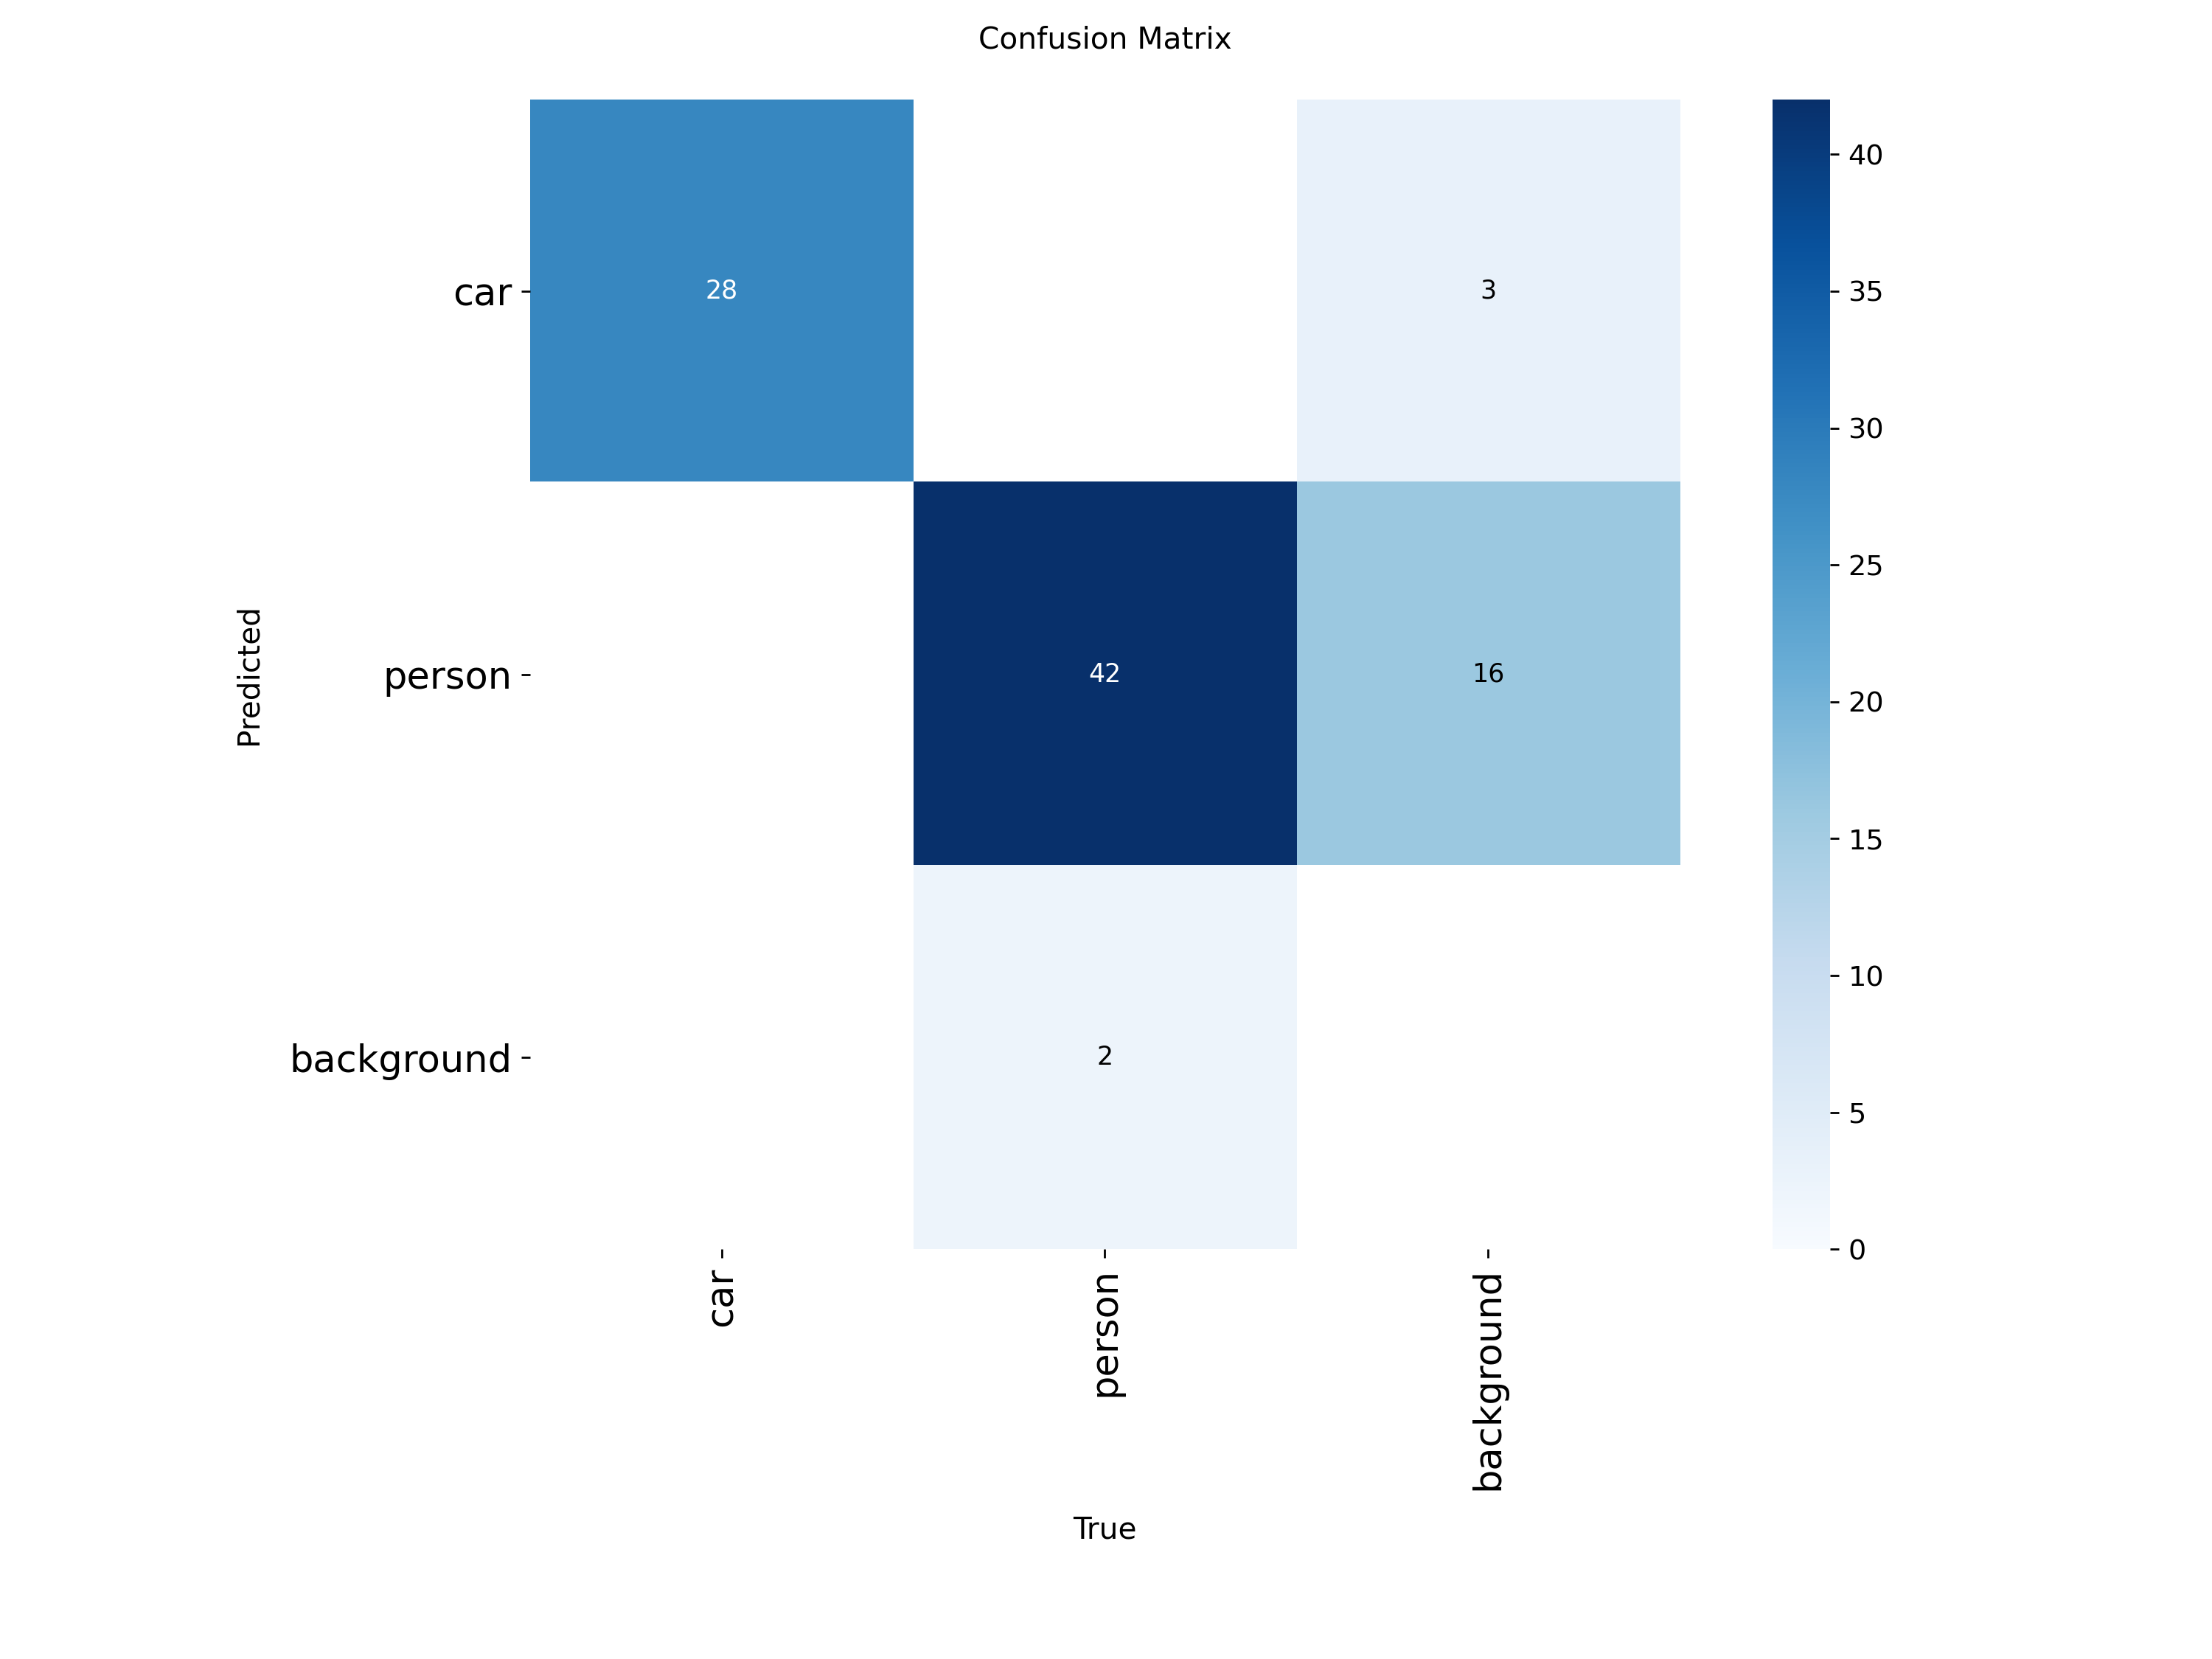


--- confusion_matrix_normalized.png ---


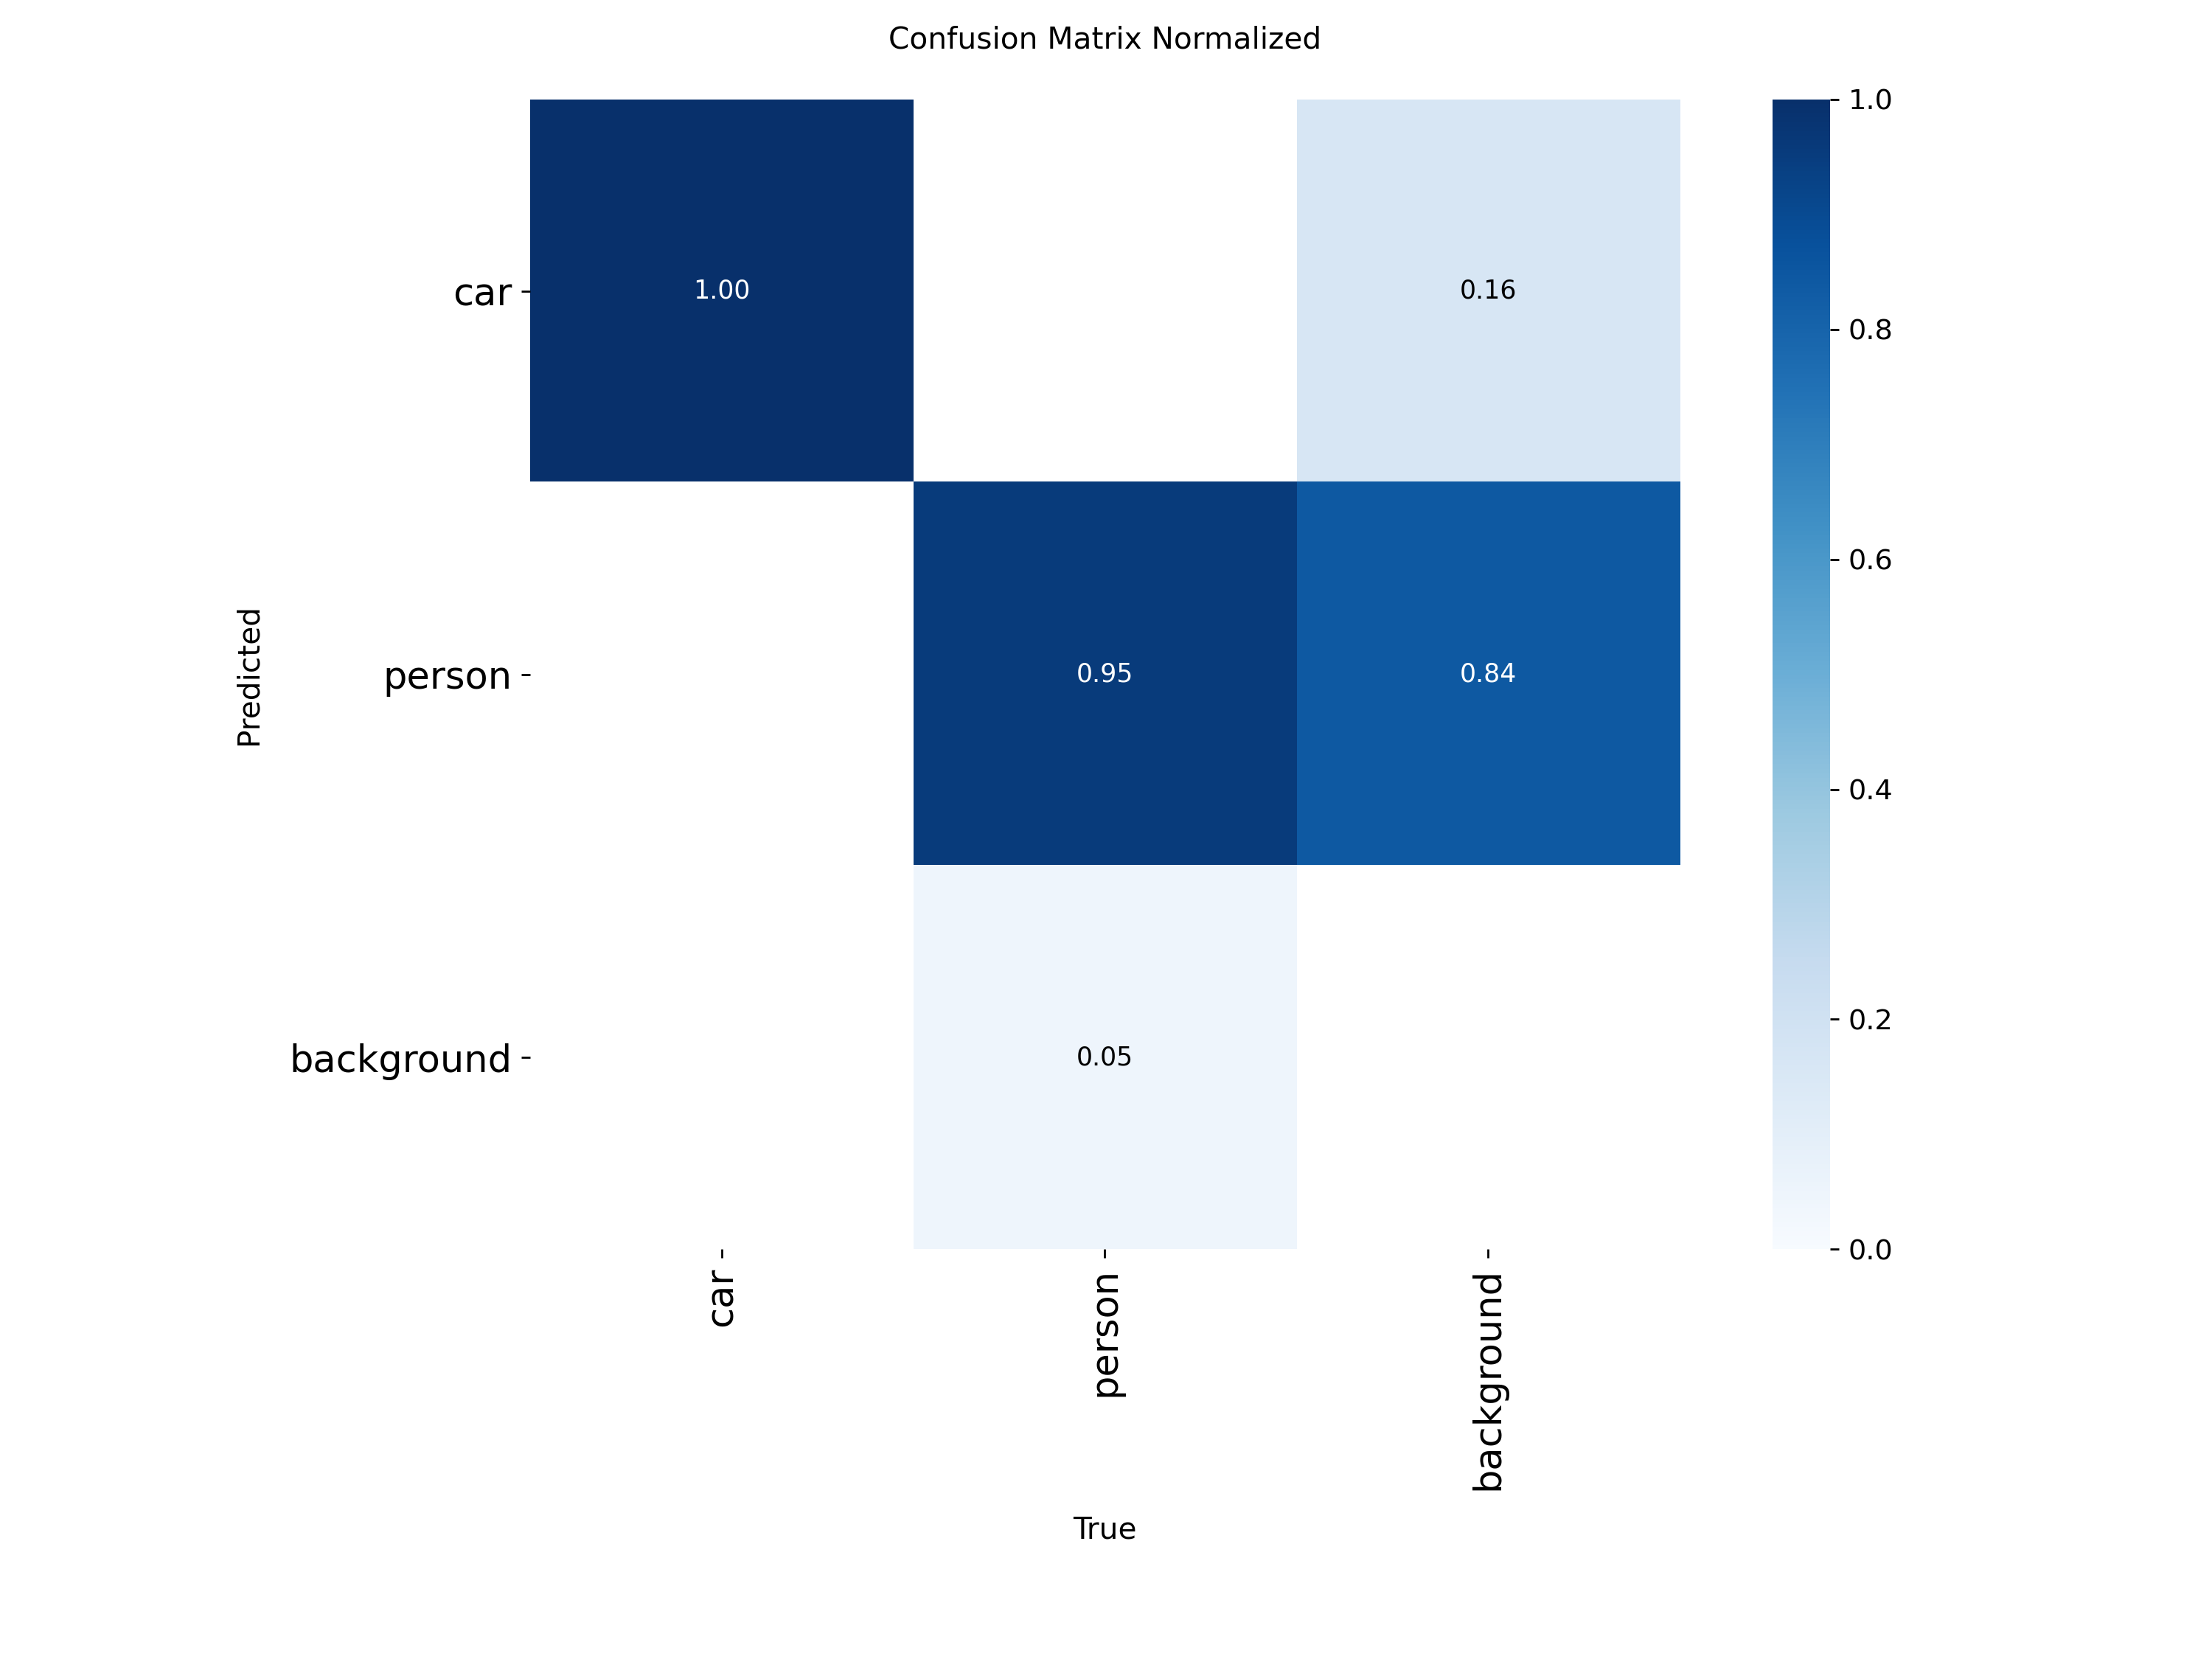


--- BoxPR_curve.png ---


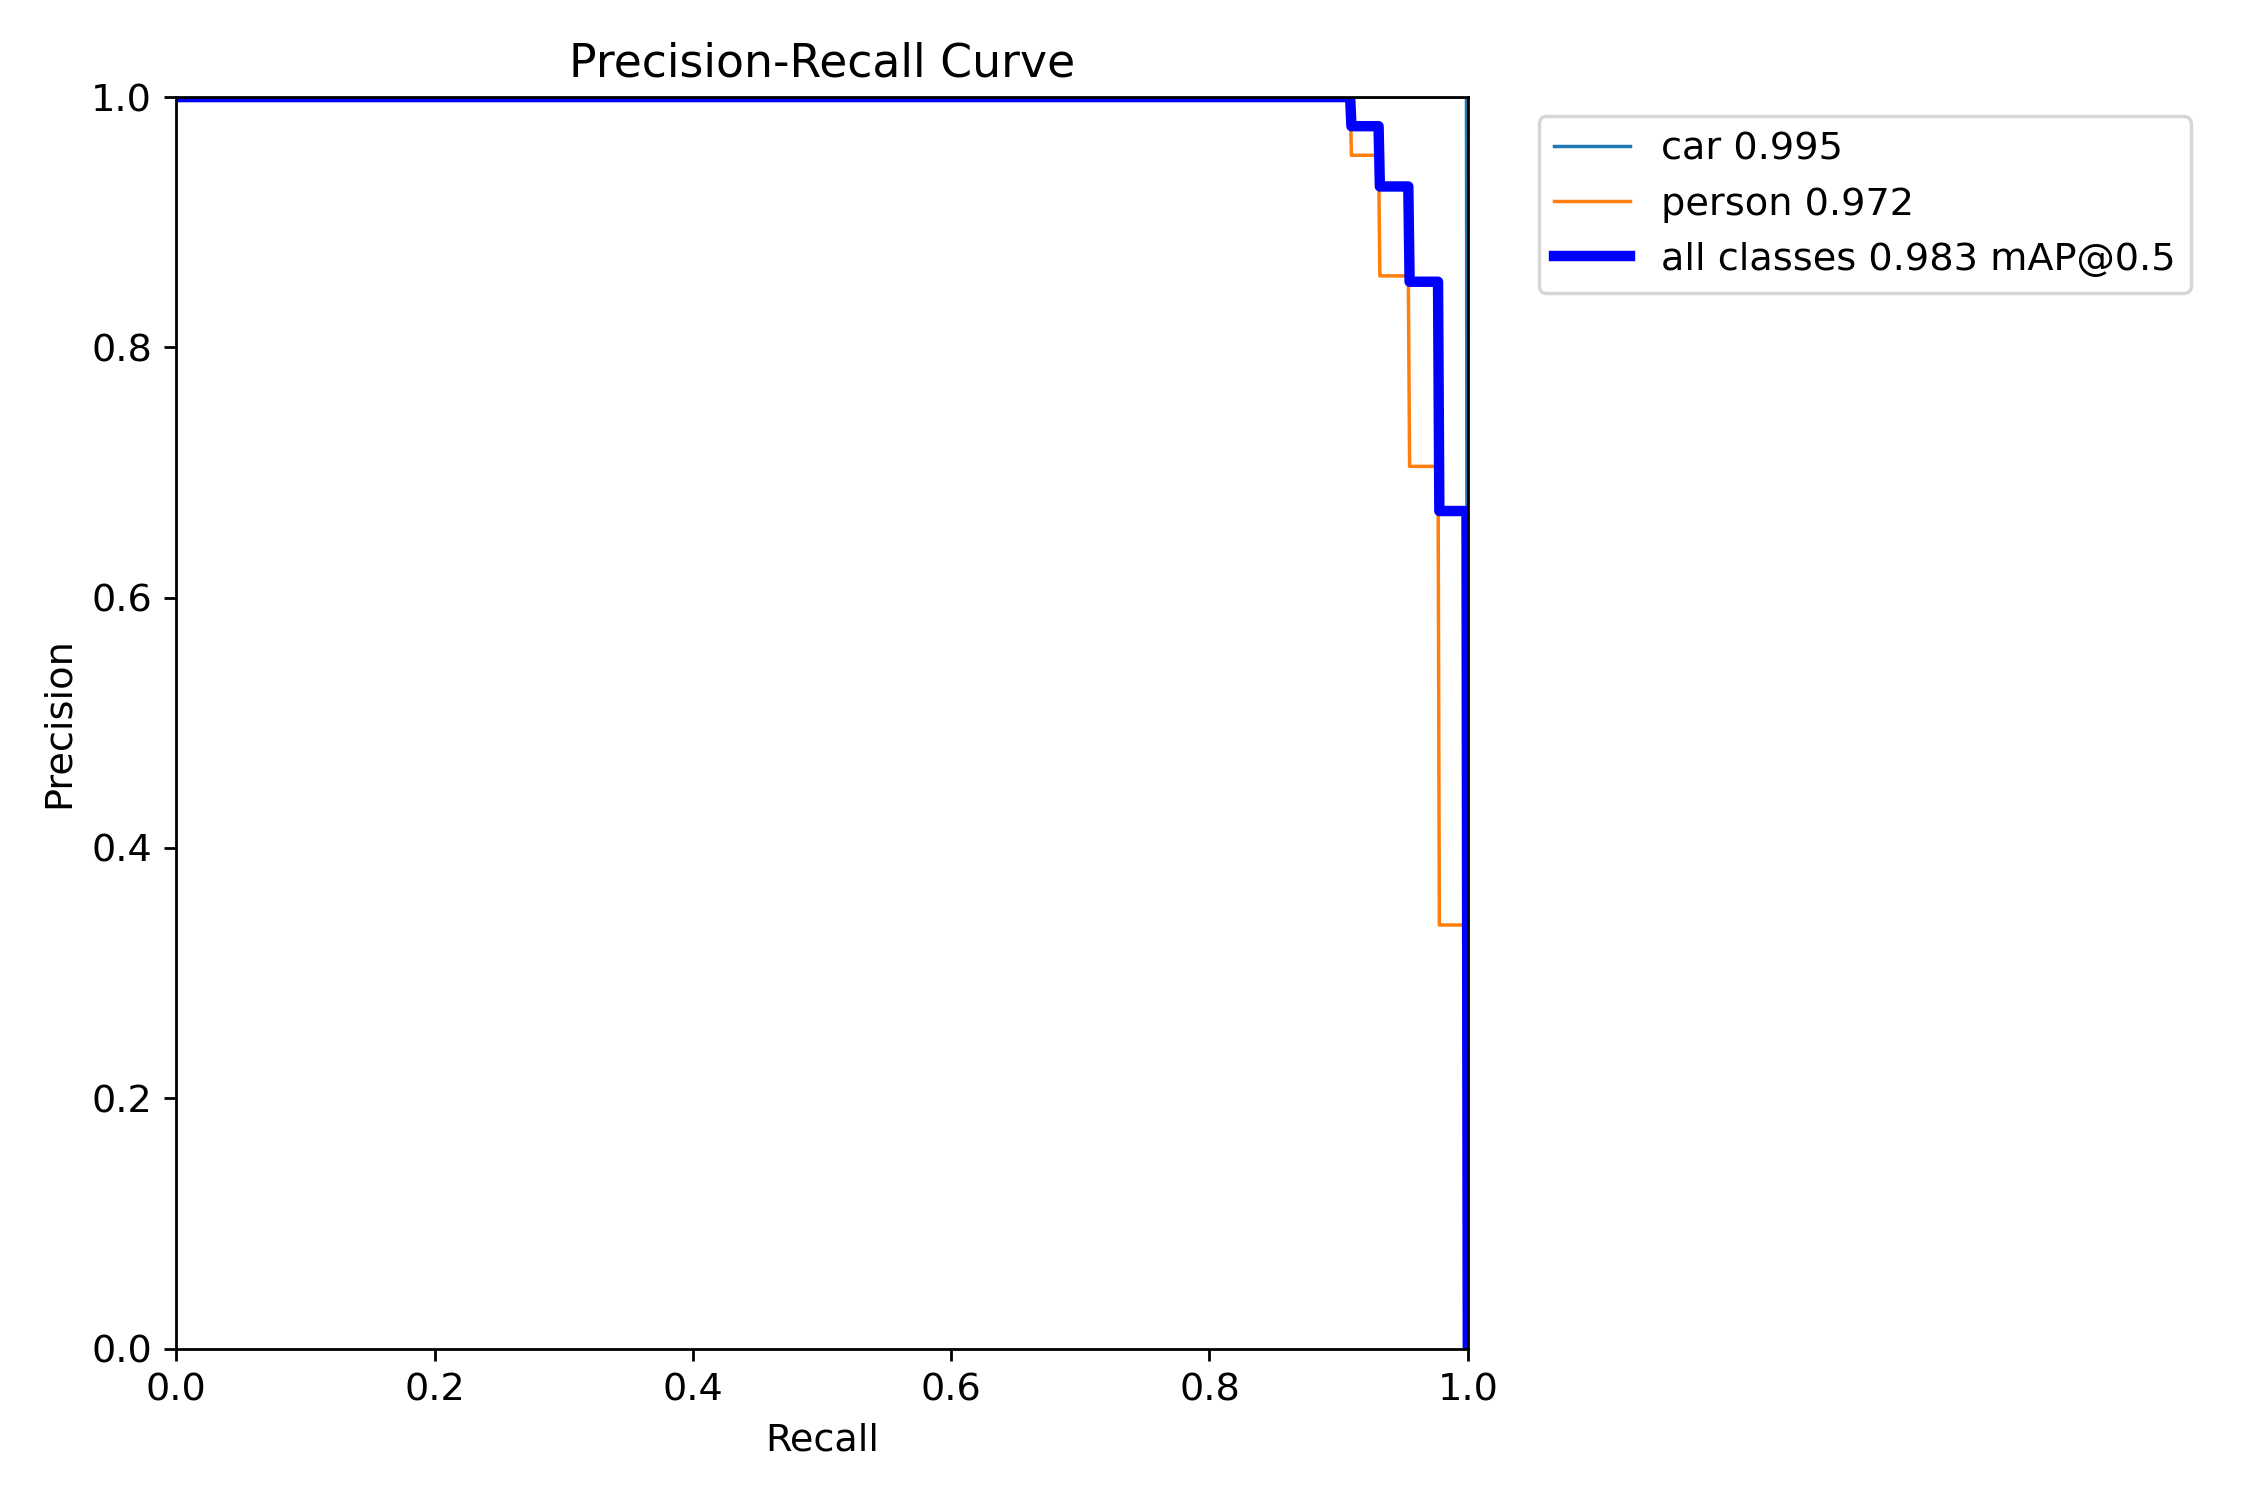


--- BoxF1_curve.png ---


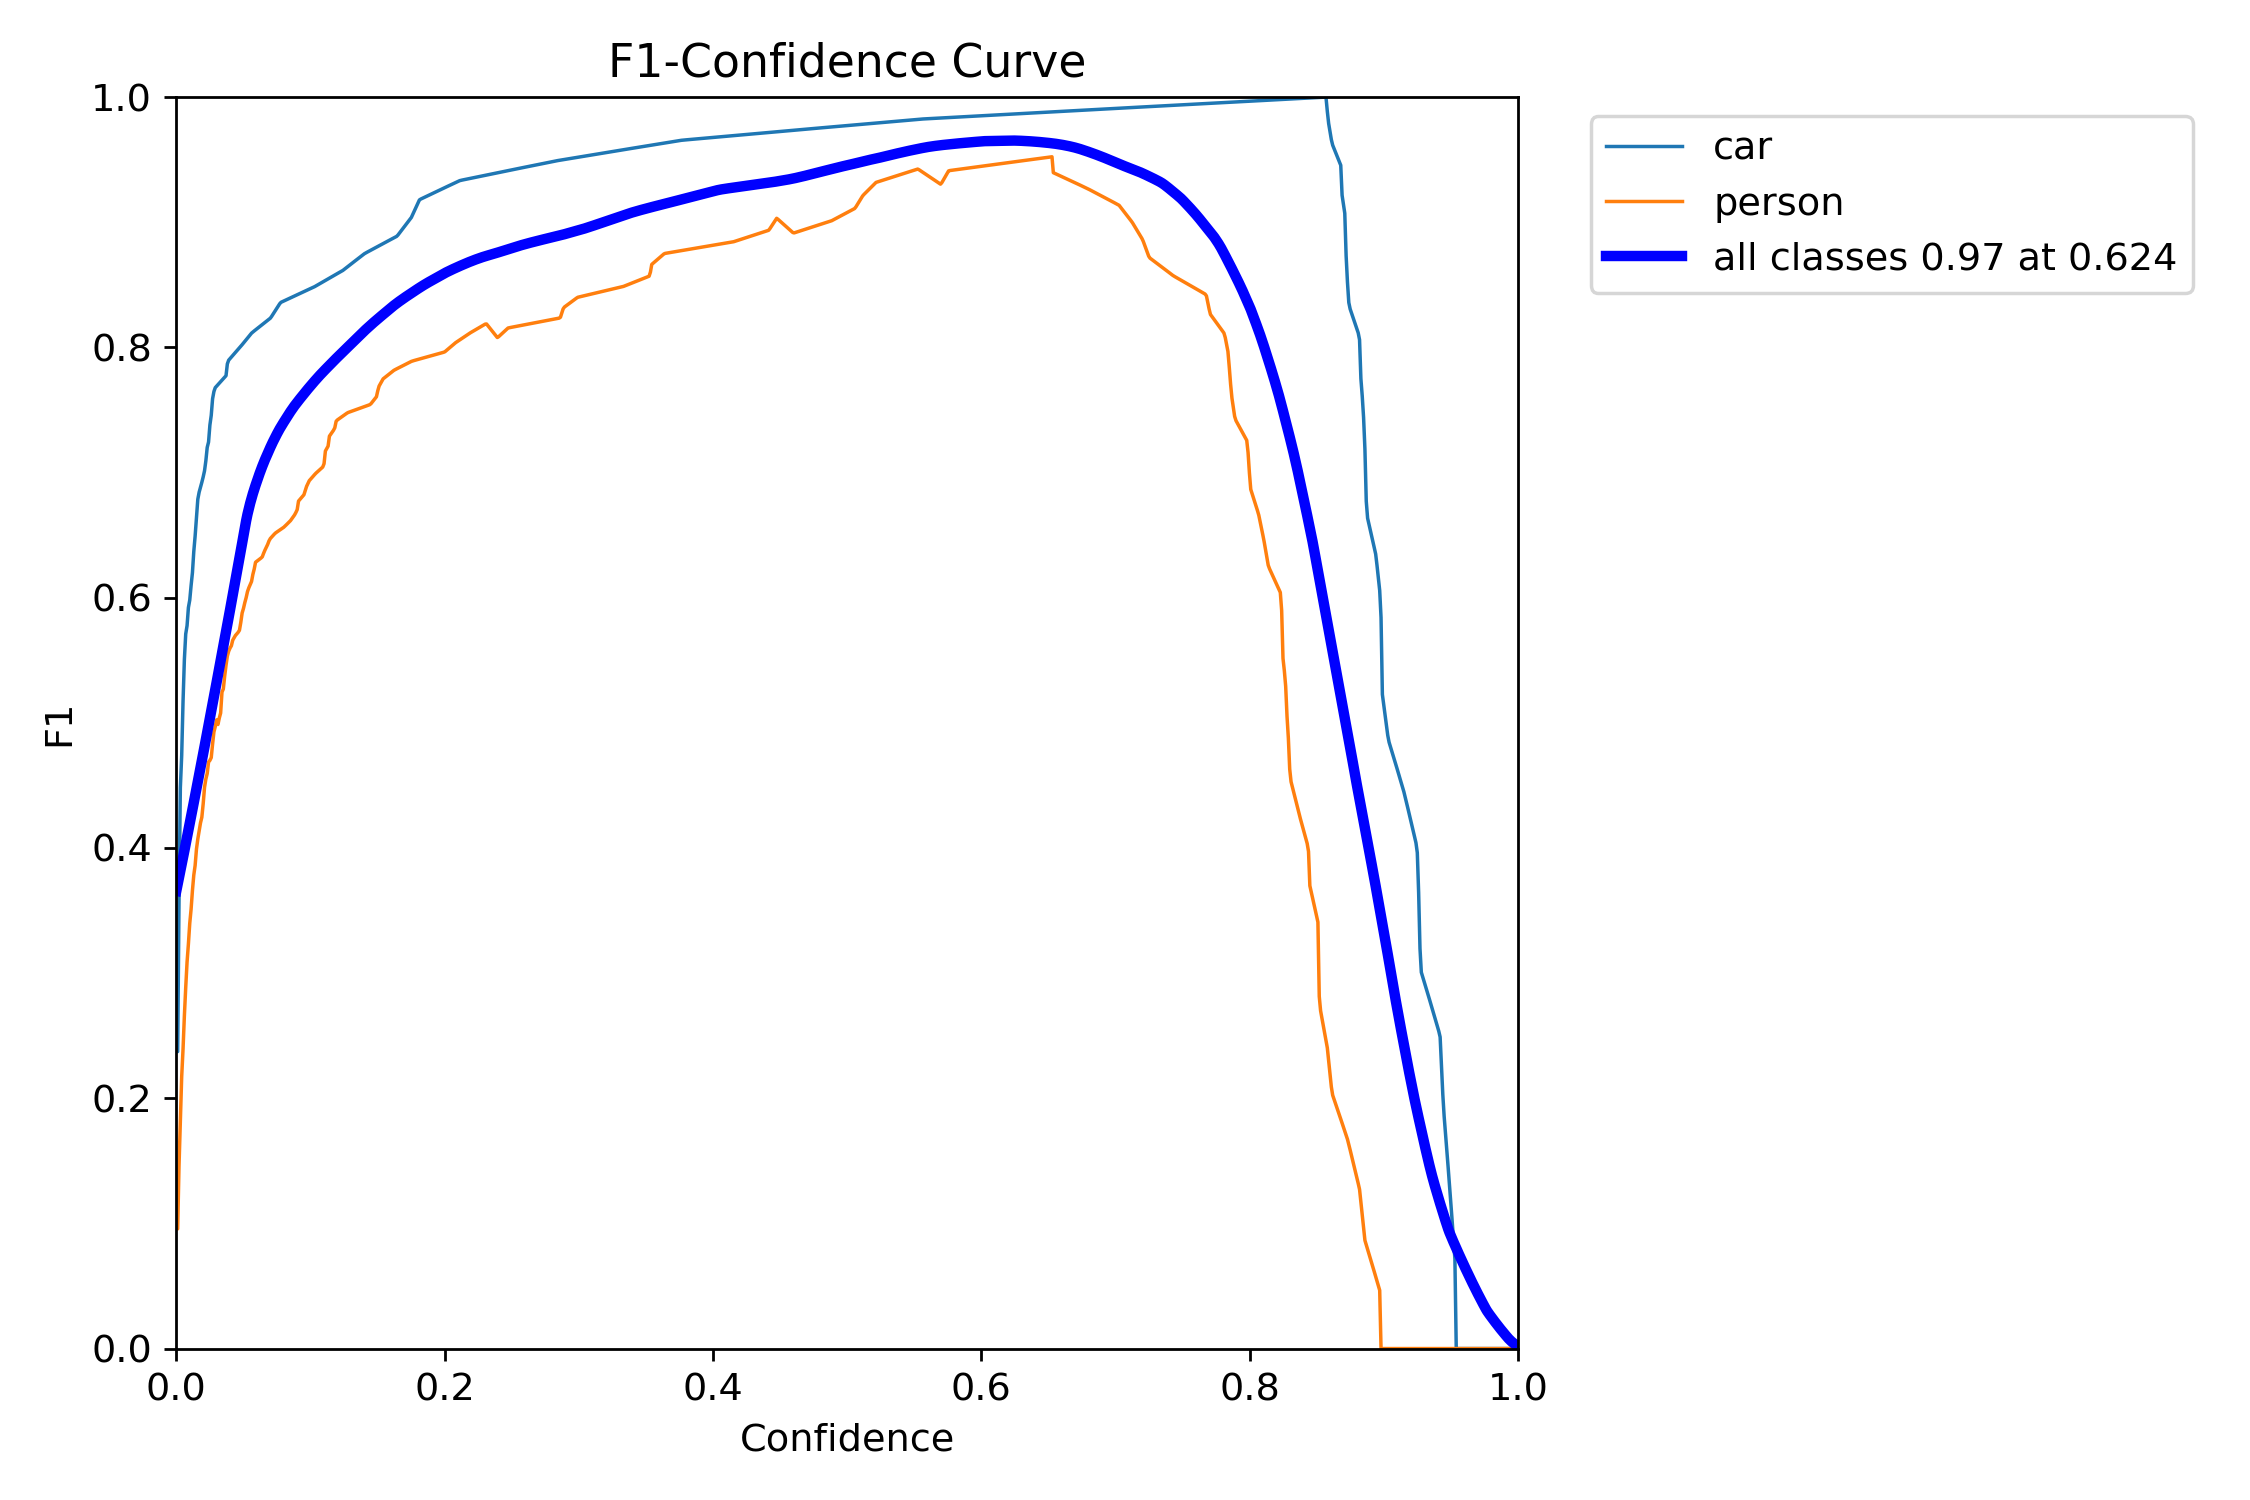


--- train_batch0.jpg ---


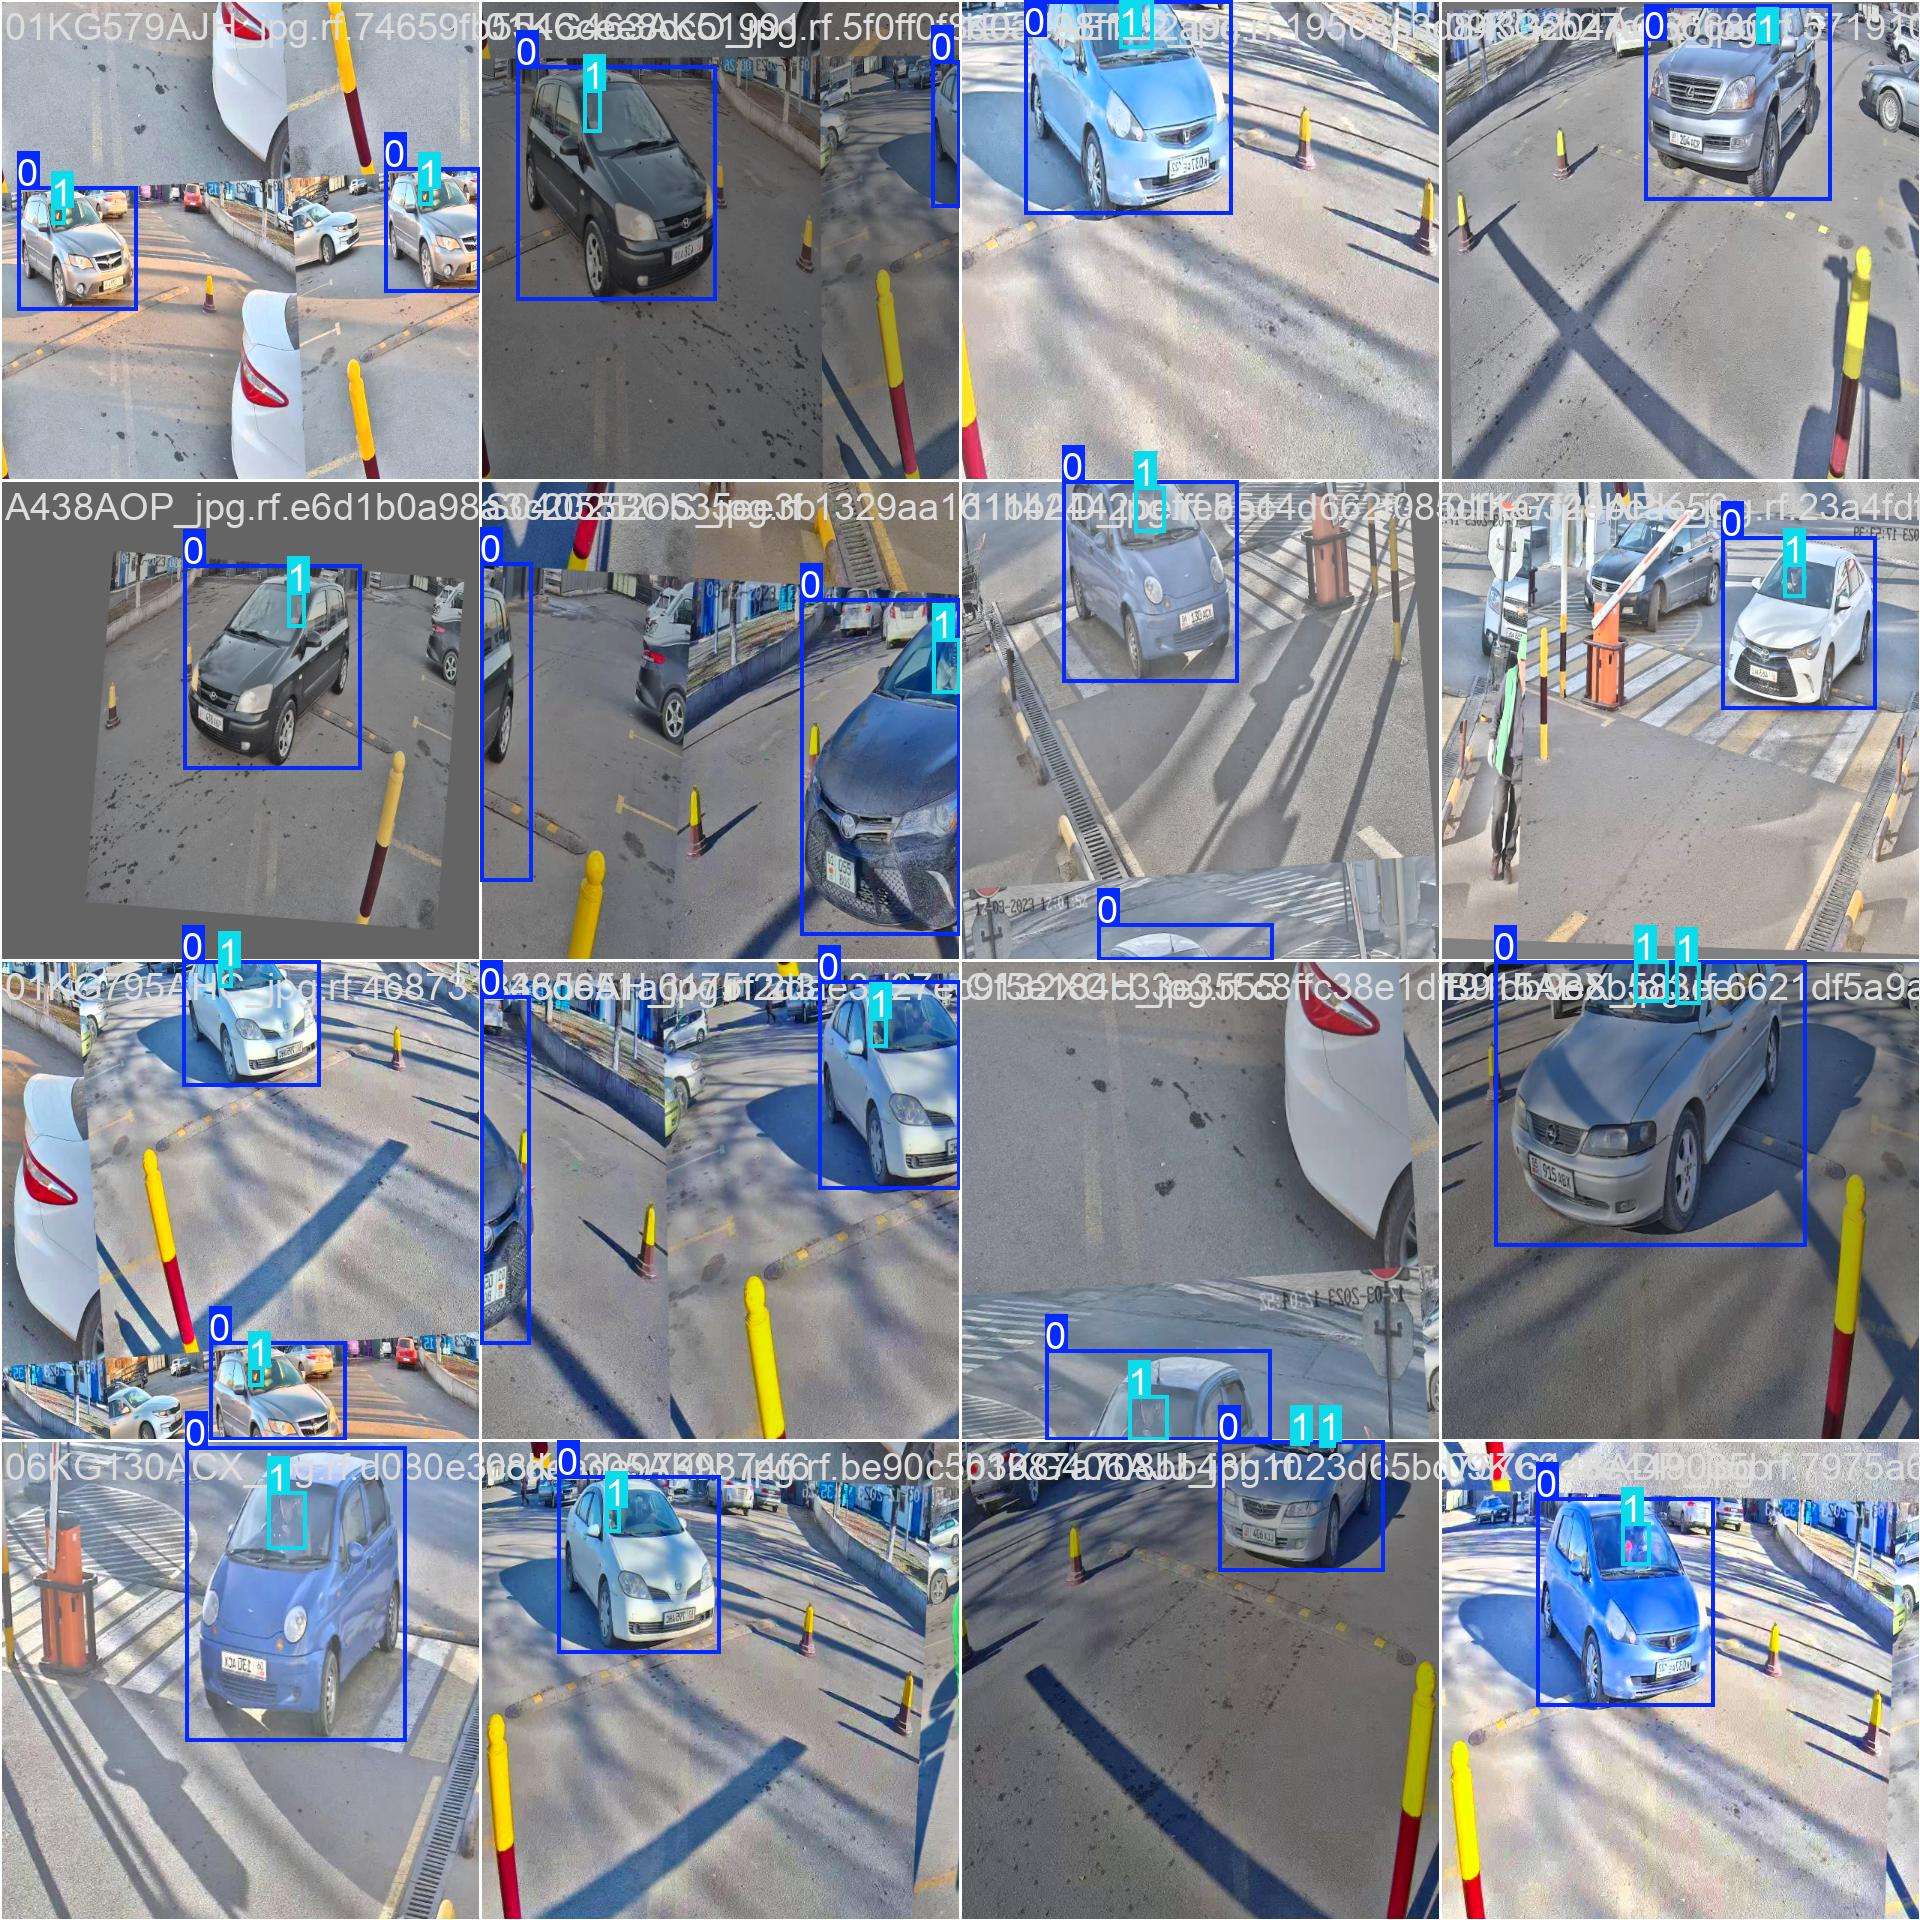


--- val_batch0_labels.jpg ---


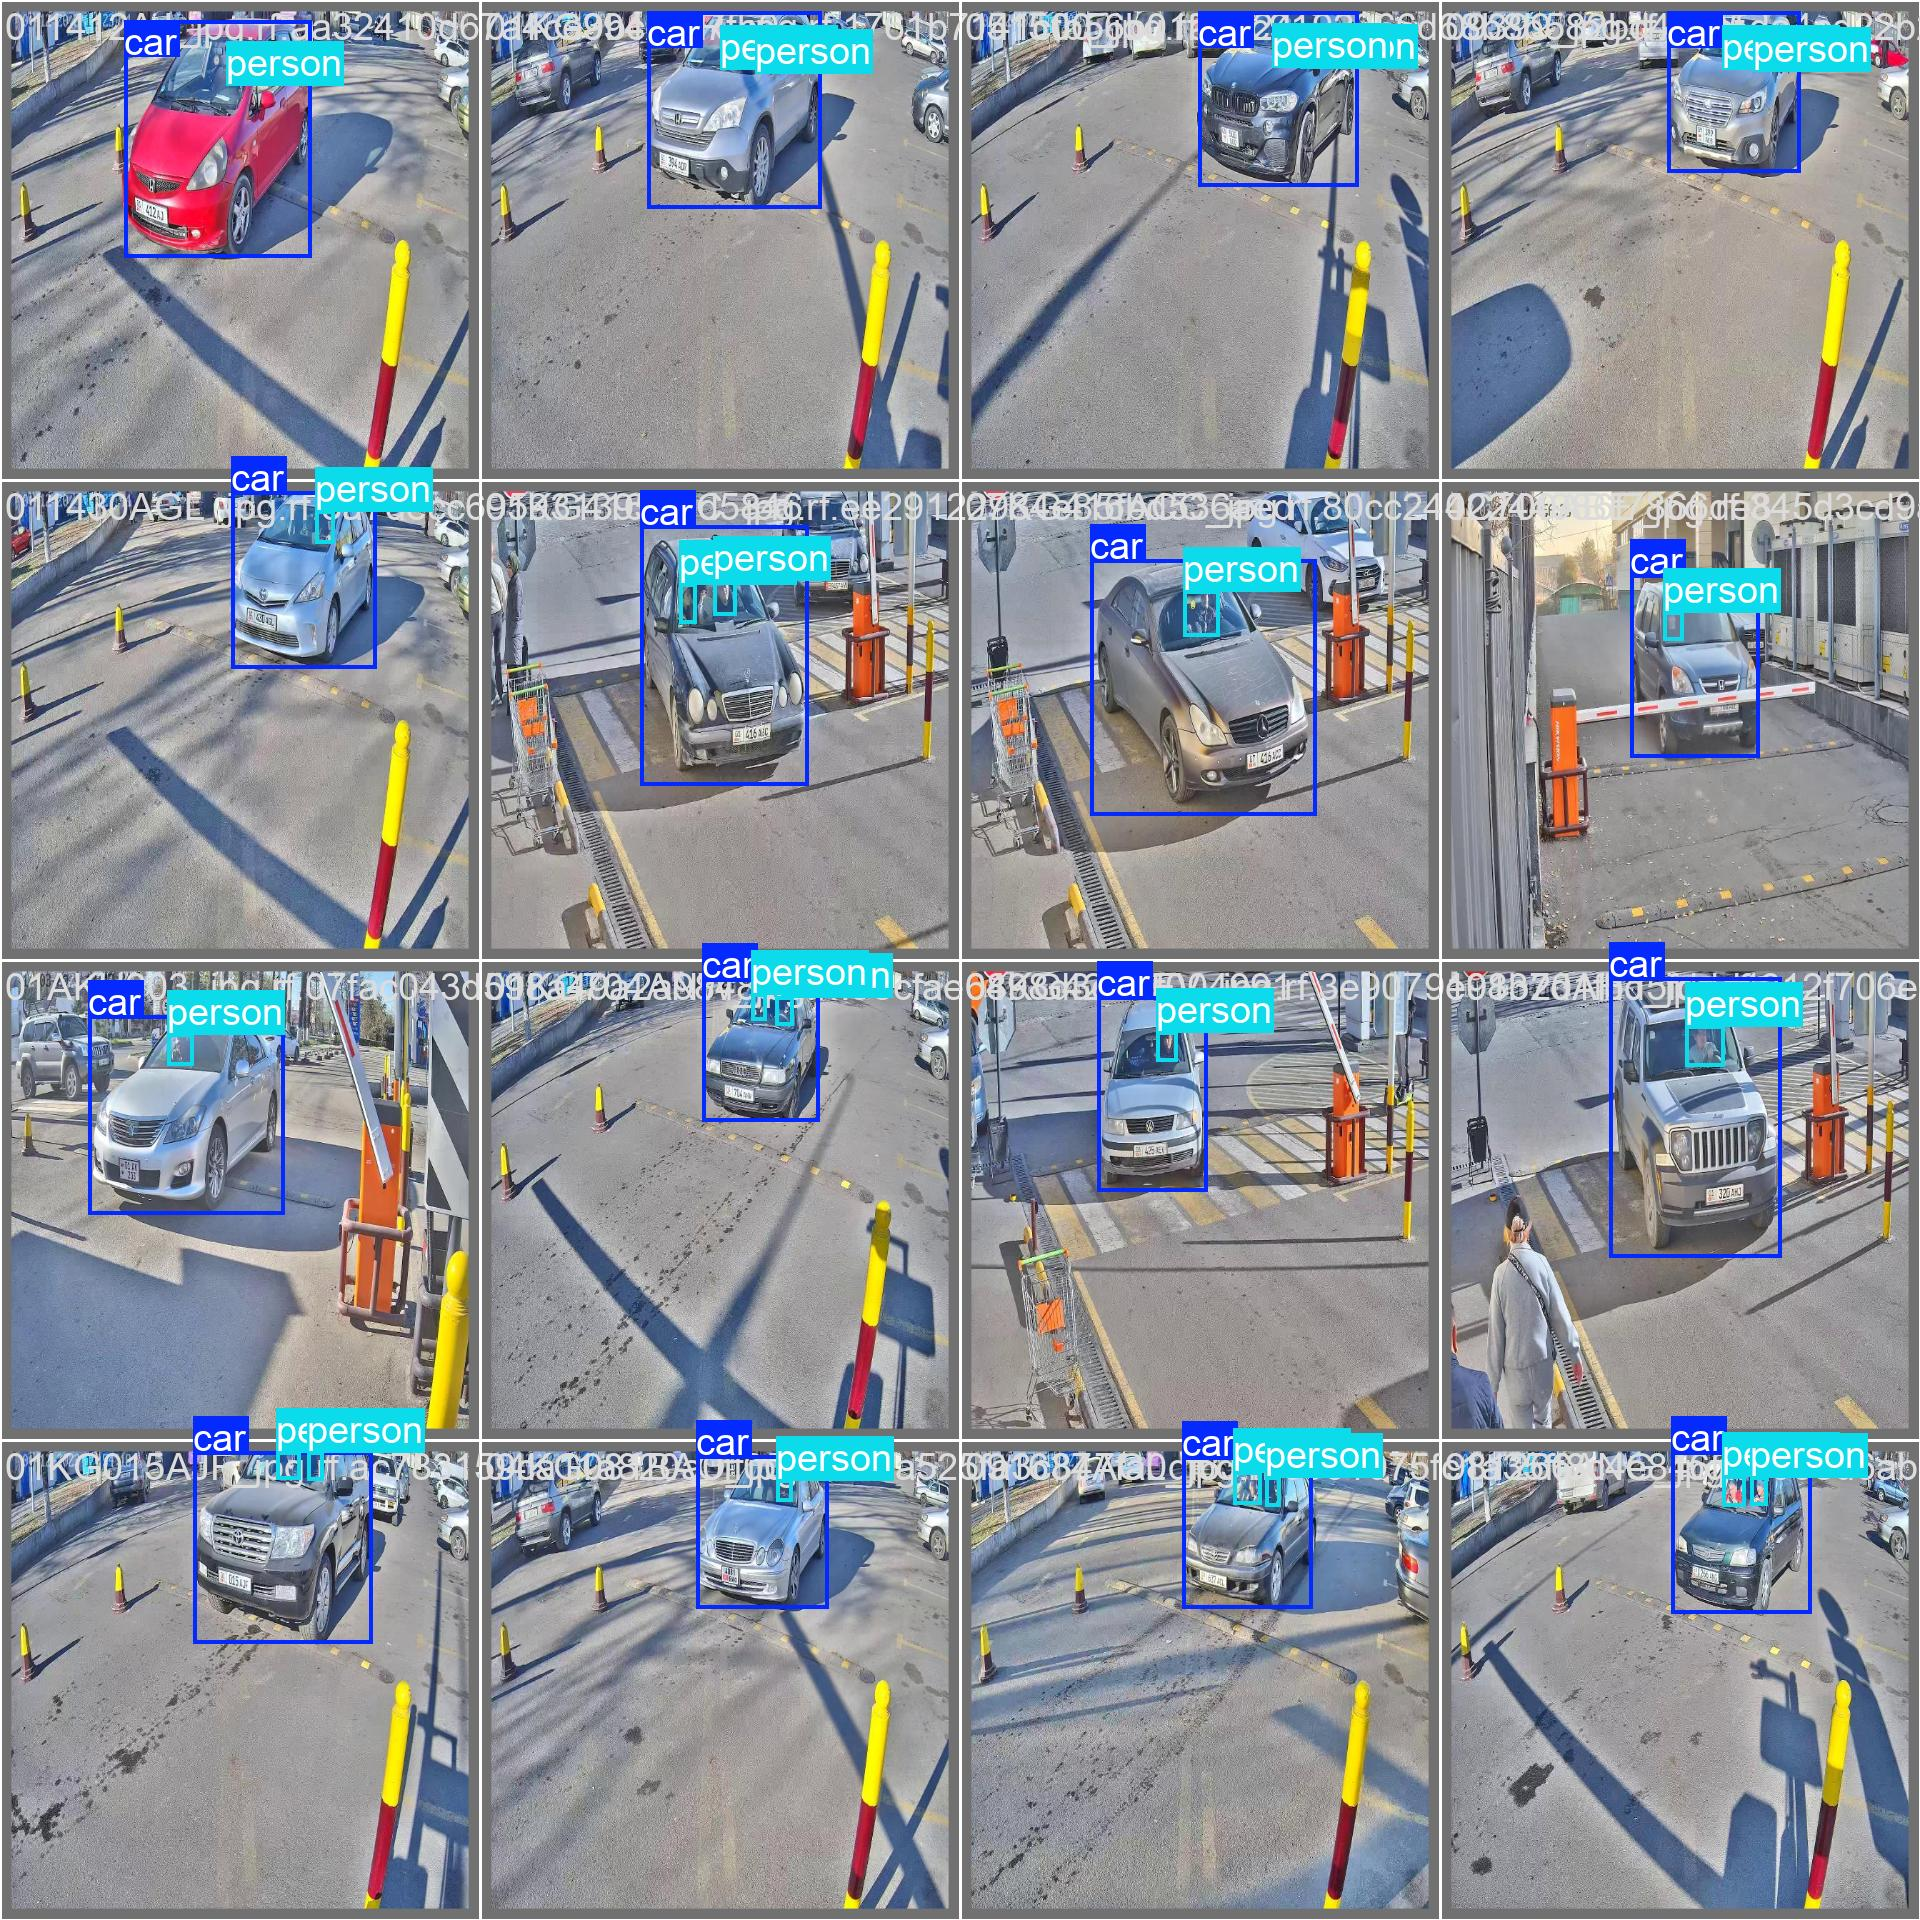


--- val_batch0_pred.jpg ---


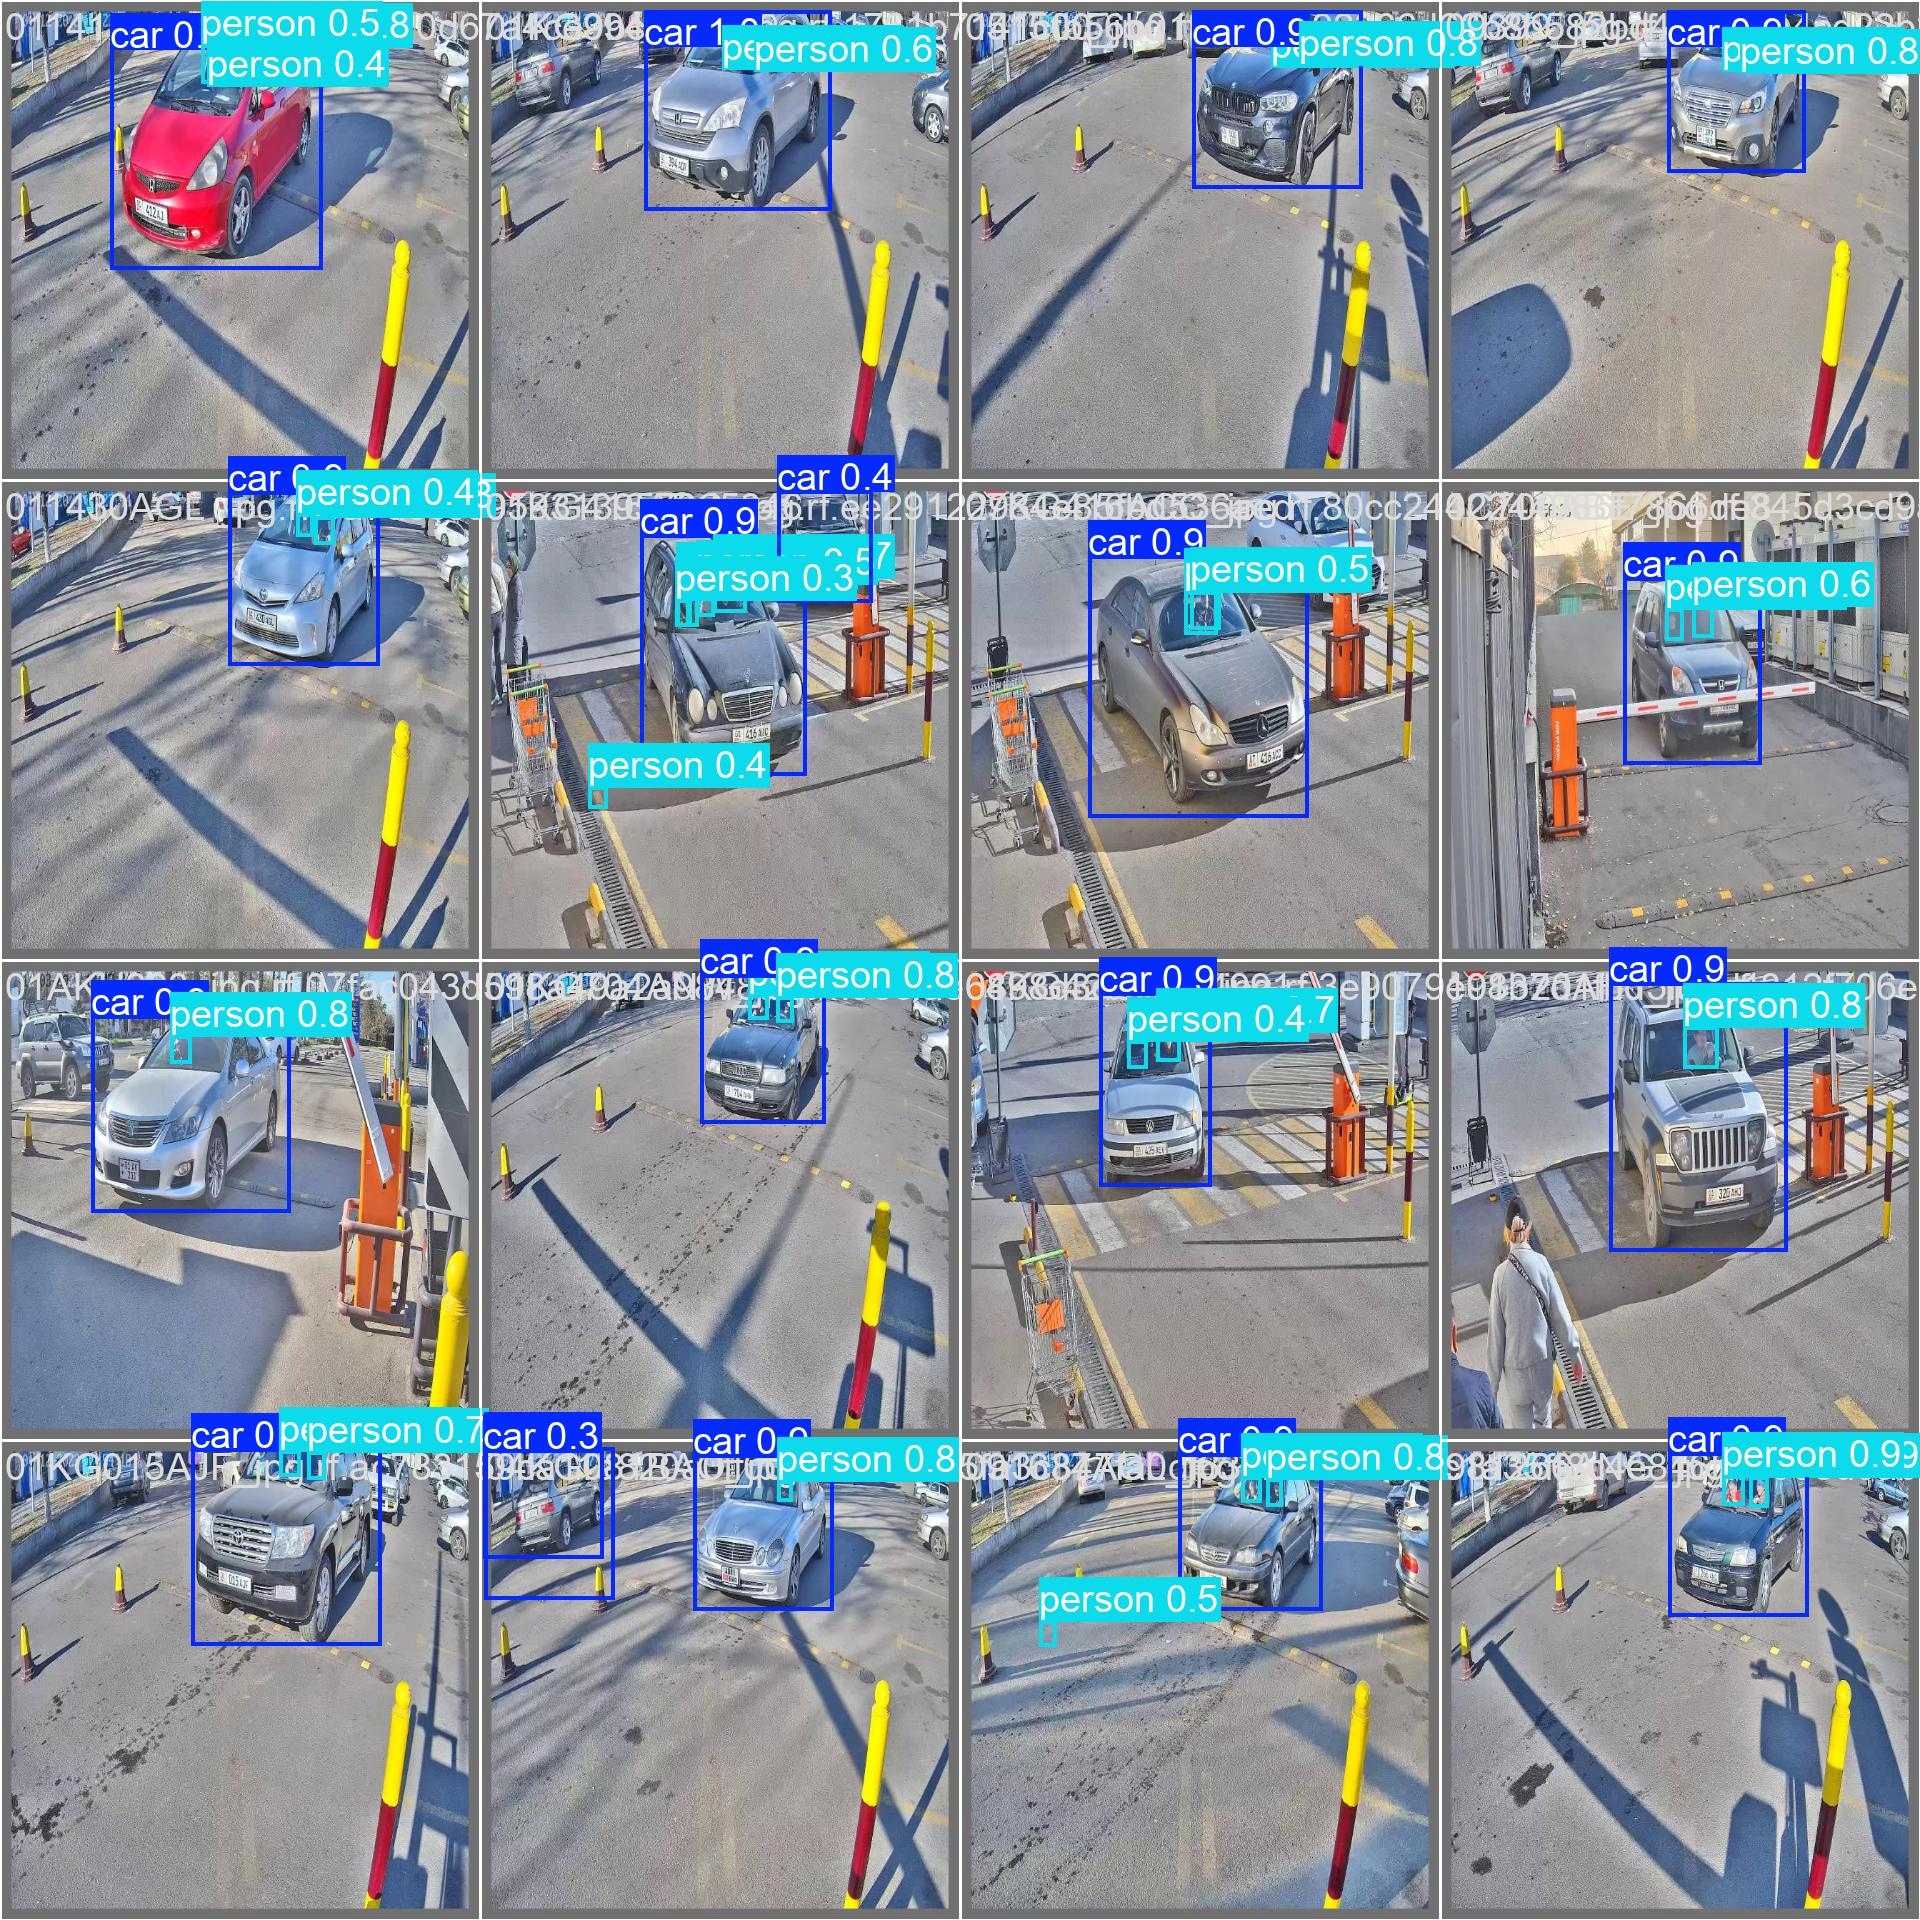

In [ ]:
from IPython.display import Image, display
import os

SAVE_DIR = "/kaggle/working/volog_runs/occupancy_v1"

# visual diagnostics help identify training issues
plots = [
    'results.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'BoxPR_curve.png',
    'BoxF1_curve.png',
    'train_batch0.jpg',
    'val_batch0_labels.jpg',
    'val_batch0_pred.jpg'
]

for plot in plots:
    path = os.path.join(SAVE_DIR, plot)
    if os.path.exists(path):
        print(f"\n--- {plot} ---")
        display(Image(path))
    else:
        print(f"Not found: {plot}")


0: 640x640 1 car, 2 persons, 13.7ms
1: 640x640 1 car, 2 persons, 13.7ms
2: 640x640 1 car, 1 person, 13.7ms
3: 640x640 1 car, 2 persons, 13.7ms
4: 640x640 1 car, 1 person, 13.7ms
Speed: 1.4ms preprocess, 13.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/volog_inference/samples


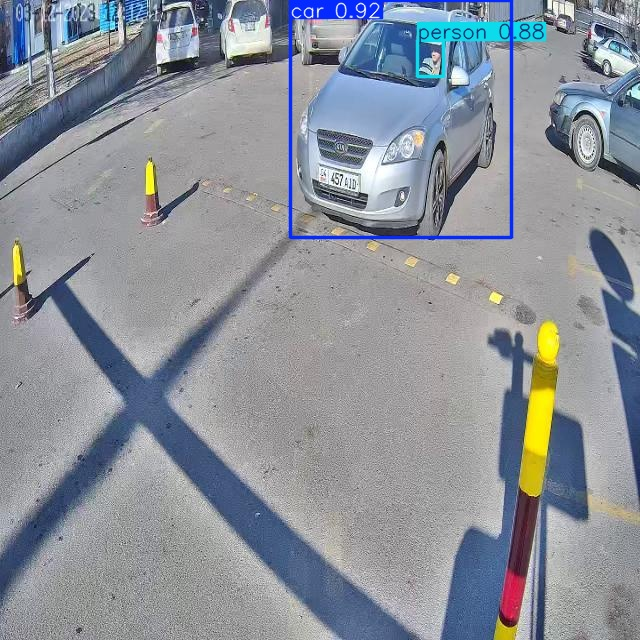

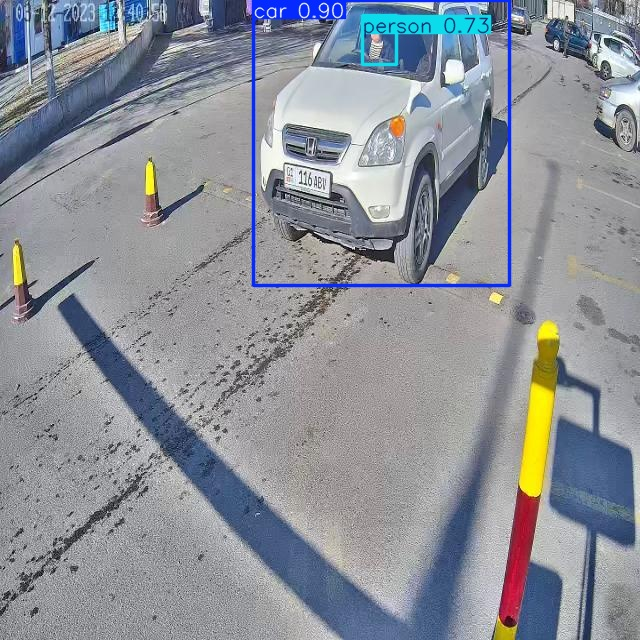

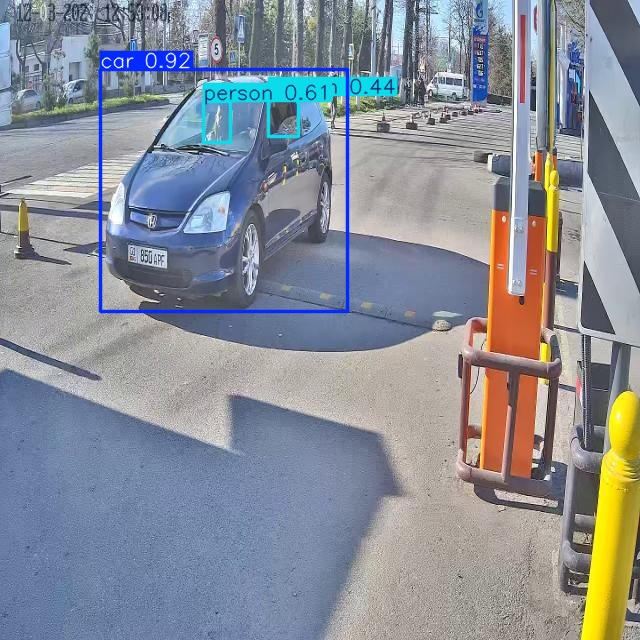

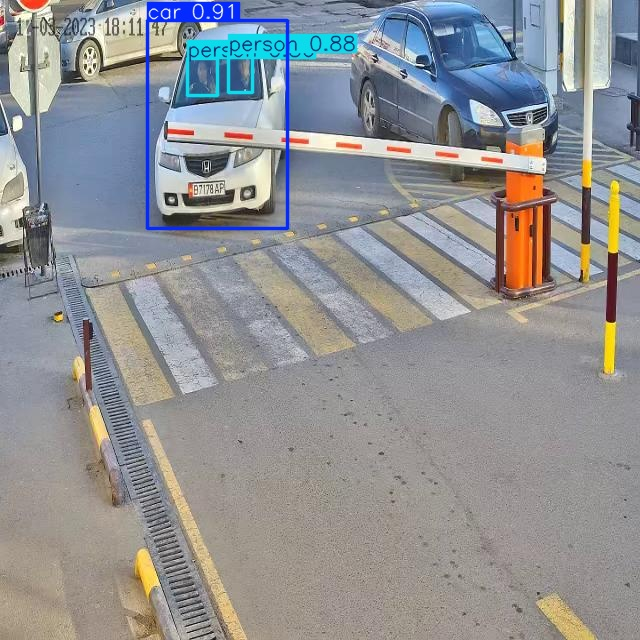

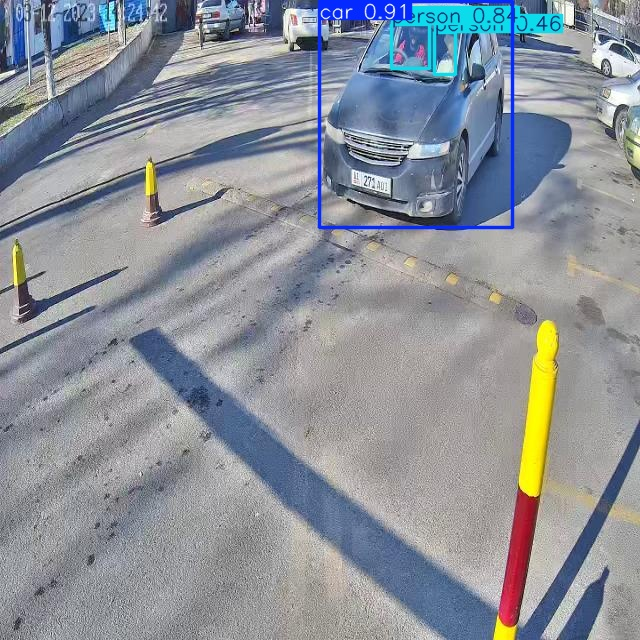

In [ ]:
import glob
from ultralytics import YOLO
from IPython.display import Image as IPImage, display

BEST_WEIGHTS = "/kaggle/working/volog_runs/occupancy_v1/weights/best.pt"
best_model   = YOLO(BEST_WEIGHTS)

# sample test images
test_img_dir  = "/kaggle/working/VOLog-2/test/images"
sample_images = (glob.glob(test_img_dir + '/*.jpg') + glob.glob(test_img_dir + '/*.png'))[:5]

if not sample_images:
    print("No test images found at:", test_img_dir)
else:
    # save predictions to inspect bounding box accuracy
    best_model.predict(
        source   = sample_images,
        imgsz    = 640,
        conf     = 0.3, # lower threshold to visualise borderline detections
        save     = True,
        project  = '/kaggle/working/volog_inference',
        name     = 'samples',
        exist_ok = True
    )

    output_imgs = glob.glob('/kaggle/working/volog_inference/samples/*.jpg')
    for img_path in output_imgs[:5]:
        display(IPImage(img_path, width=640))

In [ ]:
import shutil, os

SAVE_DIR     = "/kaggle/working/volog_runs/occupancy_v1"
BEST_WEIGHTS = SAVE_DIR + "/weights/best.pt"

# confirm training artifact exists before packaging results
if os.path.exists(BEST_WEIGHTS):
    print("best.pt confirmed at:", BEST_WEIGHTS)
else:
    print("WARNING: best.pt not found — check training completed successfully")

# archive outputs for download or sharing
zip_path = '/kaggle/working/volog_occupancy_v1_results'
shutil.make_archive(zip_path, 'zip', SAVE_DIR)

print("Results zipped to:", zip_path + '.zip')
print("\nDownload from the Output panel on the right:")
print("  best.pt       -> /kaggle/working/volog_runs/occupancy_v1/weights/best.pt")
print("  results zip   -> /kaggle/working/volog_occupancy_v1_results.zip")

best.pt confirmed at: /kaggle/working/volog_runs/occupancy_v1/weights/best.pt
Results zipped to: /kaggle/working/volog_occupancy_v1_results.zip

Download from the Output panel on the right:
  best.pt       -> /kaggle/working/volog_runs/occupancy_v1/weights/best.pt
  results zip   -> /kaggle/working/volog_occupancy_v1_results.zip
